In [8]:
# Imports y configuracion general

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN,LSTM, Input
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

In [9]:
# Crear un dataset sintetico de texto

inicios_positivos = [
    "el excelente",
    "la brillante",
    "el destacado",
    "la maravillosa",
    "el gran",
    "la experta",
    "la espectacular"
]
inicios_negativos = [
    "el terrible",
    "la pesima",
    "el deficiente",
    "la desastrosa",
    "el peor",
    "la inexperta",
    "el horrible",
    "la frustrante",
    "el ineficiente"
]
sujetos = [
    "profesor",
    "alumna",
    "investigador",
    "ingeniera",
    "medico",
    "estudiante"
]

fragmentos_ruido = [
    "que durante la extensa clase de inteligencia artificial reviso varios ejemplos",
    "mientras los estudiantes tomaban notas sin parar en sus cuadernos",
    "tratando de mantener el ritmo del temario oficial en todo momento",
    "y mirando el reloj para asegurarse de terminar a tiempo",
    "despues de analizar modelos de memoria con bastante cuidado teorico",
    "mientras comparaba resultados de entrenamiento y validacion con detalle",
    "explicando el comportamiento del gradiente en secuencias largas",
    "revisando varias arquitecturas neuronales con ejemplos comentados",
    "corrigiendo errores frecuentes en la interpretacion de los resultados",
    "mientras discutia el papel del contexto dentro del lenguaje natural",
    "despues de mostrar varios bloques de codigo en el cuaderno de colab",
    "tratando de no perder la coherencia del tema principal de la sesion"
]

cierres_neutrales = [
    "concluyo la sesion.",
    "se despidio.",
    "salio del aula.",
    "termino la explicacion.",
    "cerro la presentacion."
]

# Funcion para crear una frase larga
def construir_frase(inicio,sujeto):
  # Elegimos aleatoriamente entre 4 y 6 fragmentos distintos
  num_fragmentos = random.randint(4,6)
  ruido = random.sample(fragmentos_ruido, num_fragmentos)

  # Unimos todo en una sola frase
  frase= f"{inicio} {sujeto} "+" ".join(ruido)+ " "+ random.choice(cierres_neutrales)
  return frase

frases=[]
etiquetas=[]

# Generamos 600 ejemplos positivos
for _ in range(600):
  inicio = random.choice(inicios_positivos)
  sujeto = random.choice(sujetos)
  frases.append(construir_frase(inicio, sujeto))
  etiquetas.append(1)

# Generamos 600 ejemplos Negativos
for _ in range(600):
  inicio = random.choice(inicios_negativos)
  sujeto = random.choice(sujetos)
  frases.append(construir_frase(inicio, sujeto))
  etiquetas.append(0)

df = pd.DataFrame({"frase": frases, "etiqueta": etiquetas})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Mostramos tamaño total y ejemplo

print("Ejemplo de frase generada:\n")
print(df["frase"].iloc[0])

print("\nLongitud aproximada:", len(df["frase"].iloc[0].split()),"palabras")
print("\nTotal de ejemplos:", len(df))

print(df["etiqueta"].value_counts())

Ejemplo de frase generada:

la desastrosa ingeniera mientras comparaba resultados de entrenamiento y validacion con detalle tratando de no perder la coherencia del tema principal de la sesion que durante la extensa clase de inteligencia artificial reviso varios ejemplos mientras discutia el papel del contexto dentro del lenguaje natural salio del aula.

Longitud aproximada: 48 palabras

Total de ejemplos: 1200
etiqueta
0    600
1    600
Name: count, dtype: int64


In [4]:
# Dividir en entrenamiento y prueba

X= df["frase"].tolist()
y= df["etiqueta"].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 960
Test: 240


In [6]:
# Tokenzacion

# Creamos tokinezer OOV significa "out of vocabulary"
tokenizer = Tokenizer(oov_token="<OOV>")

# Aprendemos el vocabulario a partir del set de entrenamiento
tokenizer.fit_on_texts(X_train)

# Creamos el diccionario de palabras con indices
word_index= tokenizer.word_index

print("Tamaño del vocabulario:", len(word_index))

for i, (palabra, indice) in enumerate(word_index.items()):
  if i >= 15:
    break
  print(f"{palabra}: {indice}")

Tamaño del vocabulario: 114
<OOV>: 1
de: 2
la: 3
el: 4
del: 5
en: 6
con: 7
mientras: 8
y: 9
resultados: 10
despues: 11
tratando: 12
ejemplos: 13
los: 14
varios: 15


In [10]:
# Convertir texto a secuencias y hacer padding

# Convertir frases de entrenamiento a listas de enteros
X_train_seq = tokenizer.texts_to_sequences(X_train)

# Convertir frases de prueba a listas de enteros
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Calcular la longitud maxima observada en entrenamiento.
max_len= max(len(seq) for seq in X_train_seq)

X_train_pad =pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

print(" Tamaño X_train_pad:", X_train_pad.shape)
print(" Tamaño X_test_pad:", X_test_pad.shape)

print("\nFrase original:")
print(X_train[0])
print("\nFrase tokenizada:")
print(X_train_seq[0])
print("\nFrase paddeada:")
print(X_train_pad[0])

 Tamaño X_train_pad: (960, 72)
 Tamaño X_test_pad: (240, 72)

Frase original:
el deficiente investigador despues de mostrar varios bloques de codigo en el cuaderno de colab explicando el comportamiento del gradiente en secuencias largas revisando varias arquitecturas neuronales con ejemplos comentados corrigiendo errores frecuentes en la interpretacion de los resultados que durante la extensa clase de inteligencia artificial reviso varios ejemplos concluyo la sesion.

Frase tokenizada:
[4, 106, 97, 11, 2, 49, 15, 50, 2, 51, 6, 4, 52, 2, 53, 33, 4, 34, 5, 35, 6, 36, 37, 44, 45, 46, 47, 7, 13, 48, 54, 55, 56, 6, 3, 57, 2, 14, 10, 65, 66, 3, 67, 68, 2, 69, 70, 71, 15, 13, 94, 3, 16]

Frase paddeada:
[  4 106  97  11   2  49  15  50   2  51   6   4  52   2  53  33   4  34
   5  35   6  36  37  44  45  46  47   7  13  48  54  55  56   6   3  57
   2  14  10  65  66   3  67  68   2  69  70  71  15  13  94   3  16   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [11]:
# Modelo simple RNN

vocab_size= len(word_index)+1

embedding_dim= 32

modelo_rnn = Sequential()

modelo_rnn.add(Input(shape=(max_len,)))

modelo_rnn.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True))

modelo_rnn.add(SimpleRNN(32, activation="tanh"))

modelo_rnn.add(Dense(1, activation="sigmoid"))

modelo_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 72, 32)         │         3,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,793 (22.63 KB)

 Trainable params: 5,793 (22.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Modelo LSTM

modelo_lstm = Sequential()
modelo_lstm.add(Input(shape=(max_len,)))

modelo_lstm.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True))

modelo_lstm.add(LSTM(32))

modelo_lstm.add(Dense(1, activation="sigmoid"))

modelo_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 72, 32)         │         3,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Entrenamos ambos modelos

hist_rnn= modelo_rnn.fit(
    X_train_pad,
    np.array(y_train),
    batch_size=32,
    epochs=18,
    validation_split=0.2,
    verbose=1
)

hist_lstm= modelo_lstm.fit(
    X_train_pad,
    np.array(y_train),
    batch_size=32,
    epochs=18,
    validation_split=0.2,
    verbose=1
)

Epoch 1/18
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.4948 - loss: 0.7025 - val_accuracy: 0.4792 - val_loss: 0.6912
Epoch 2/18
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6940 - loss: 0.6269 - val_accuracy: 0.7552 - val_loss: 0.5100
Epoch 3/18
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7773 - loss: 0.4510 - val_accuracy: 0.8073 - val_loss: 0.3986
Epoch 4/18
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8698 - loss: 0.2980 - val_accuracy: 0.9323 - val_loss: 0.2132
Epoch 5/18
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9635 - loss: 0.1500 - val_accuracy: 0.9531 - val_loss: 0.1322
Epoch 6/18
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9635 - loss: 0.1192 - val_accuracy: 0.9427 - val_loss: 0.1540
Epoch 7/18
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9805 - loss: 0.0869 - val_accuracy: 0.9948 - val_loss: 0.0642
Epoch 8/18
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9857 - loss: 0.0566 - val_accuracy: 0.9688 - v

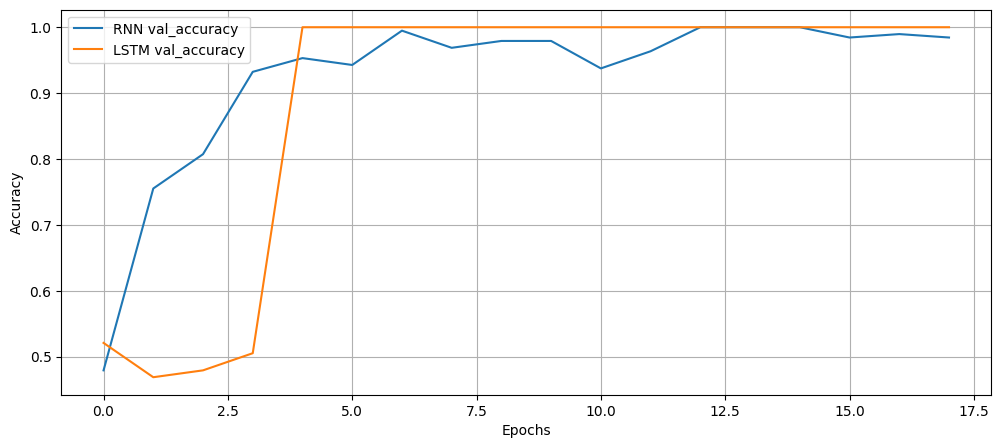

In [16]:
# Graficar curvas de validacion

plt.figure(figsize=(12,5))
plt.plot(hist_rnn.history["val_accuracy"], label="RNN val_accuracy")
plt.plot(hist_lstm.history["val_accuracy"], label="LSTM val_accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Prueba con frases nuevas

frases_nuevas = [
    "el excelente profesor que durante la extensa clase de inteligencia artificial reviso varios ejemplos "
    "mientras los estudiantes tomaban notas sin parar en sus cuadernos "
    "tratando de mantener el ritmo del temario oficial en todo momento "
    "despues de analizar modelos de memoria con bastante cuidado teorico "
    "concluyo la sesion.",

    "el terrible profesor que durante la extensa clase de inteligencia artificial reviso varios ejemplos "
    "mientras los estudiantes tomaban notas sin parar en sus cuadernos "
    "tratando de mantener el ritmo del temario oficial en todo momento "
    "despues de analizar modelos de memoria con bastante cuidado teorico "
    "concluyo la sesion.",

    "la brillante alumna que mientras comparaba resultados de entrenamiento y validacion con detalle "
    "explicando el comportamiento del gradiente en secuencias largas "
    "revisando varias arquitecturas neuronales con ejemplos comentados "
    "corrigiendo errores frecuentes en la interpretacion de los resultados "
    "se despidio.",

    "la pesima alumna que mientras comparaba resultados de entrenamiento y validacion con detalle "
    "explicando el comportamiento del gradiente en secuencias largas "
    "revisando varias arquitecturas neuronales con ejemplos comentados "
    "corrigiendo errores frecuentes en la interpretacion de los resultados "
    "se despidio."
]

seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)

pad_nuevas = pad_sequences(seq_nuevas, maxlen=max_len, padding="post")

predicciones_rnn = modelo_rnn.predict(pad_nuevas)
predicciones_lstm = modelo_lstm.predict(pad_nuevas)
for i, frase in enumerate(frases_nuevas):
  print(f"Frase {i+1}:")
  print(frase)
  print(f" SimpleRNN: {predicciones_rnn[i][0]:.4f}")
  print(f" LSTM: {predicciones_lstm[i][0]:.4f}")
  print("-"*90)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Frase 1:
el excelente profesor que durante la extensa clase de inteligencia artificial reviso varios ejemplos mientras los estudiantes tomaban notas sin parar en sus cuadernos tratando de mantener el ritmo del temario oficial en todo momento despues de analizar modelos de memoria con bastante cuidado teorico concluyo la sesion.
 SimpleRNN: 0.9959
 LSTM: 0.9987
------------------------------------------------------------------------------------------
Frase 2:
el terrible profesor que durante la extensa clase de inteligencia artificial reviso varios ejemplos mientras los estudiantes tomaban notas sin parar en sus cuadernos tratando de mantener el ritmo del temario oficial en todo momento despues de analizar modelos de memoria con bastante cuidado teorico concluyo la sesion.
 SimpleRNN: 0.0050
 LSTM: 0.0014
------------------------------------------------------------------------------------------
Frase 3:
la brill